## Comparar os Modelos


In [1]:
# Importa a biblioteca usada para carregar e manipular os dados em formato de tabela
import pandas as pd

# Lê o dataset já tratado a partir da pasta de dados
df = pd.read_csv('../data/breast-cancer-wisconsin-data-clean.csv')

# Separa a variável alvo (diagnóstico) das variáveis preditoras
y = df['diagnostico']
X = df.drop(columns=['diagnostico'])

# Exibe o formato dos dados para confirmar a estrutura usada no treinamento
print(X.shape)
print(y.shape)
print('Quantidade de colunas usadas no modelo:', len(X.columns))

# Divide os dados entre treino e teste para avaliar a capacidade de generalização do modelo
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Padroniza as variáveis numéricas com base apenas no conjunto de treino
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X_train)

# Aplica a mesma transformação nos conjuntos de treino e teste
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

(569, 30)
(569,)
Quantidade de colunas usadas no modelo: 30


In [15]:
# Importa novamente o pandas para garantir que a célula seja independente
import pandas as pd

# Importa os algoritmos que serão comparados
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

# Importa as métricas usadas para avaliar o desempenho dos modelos
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Define um conjunto de modelos base para comparação inicial
modelos = {
    'Regressão Logística': LogisticRegression(max_iter=1000, random_state=42),
    'Árvore de Decisão': DecisionTreeClassifier(max_depth=5, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'KNN k=9': KNeighborsClassifier(n_neighbors=9)
}

# Cria uma lista para armazenar os resultados consolidados de cada modelo
resultados = []

# Treina cada modelo, faz previsões e calcula as métricas de interesse
for nome, modelo in modelos.items():
    modelo.fit(X_train_scaled, y_train)
    y_pred = modelo.predict(X_test_scaled)

    resultados.append({
        'Modelo': nome,
        'Acurácia': accuracy_score(y_test, y_pred),
        'Precisão Classe 1': precision_score(y_test, y_pred, pos_label=1),
        'Recall Classe 1': recall_score(y_test, y_pred, pos_label=1),
        'F1-score Classe 1': f1_score(y_test, y_pred, pos_label=1)
    })

# Converte a lista de resultados em DataFrame para facilitar a comparação
df_resultados = pd.DataFrame(resultados)
df_resultados

,Modelo,Acurácia,Precisão Classe 1,Recall Classe 1,F1-score Classe 1
0,Regressão Logística,0.973684,0.976190,0.953488,0.964706
1,Árvore de Decisão,0.947368,0.930233,0.930233,0.930233
2,KNN,0.947368,0.930233,0.930233,0.930233
3,KNN k=9,0.964912,0.953488,0.953488,0.953488


### Análise

- Precisão Classe 1 = 0.976190
- Recall Classe 1 = 0.953488
- F1-score Classe 1 = 0.964706

Precisão 0.976190:
Quando a Regressão Logística disse que era maligno, acertou 97,62% das vezes.

Recall 0.953488:
De todos os casos malignos reais, encontrou 95,35%.

F1-score 0.964706:
Teve um equilíbrio muito bom entre precisão e recall.

### Matriz de confusão para todos os modelos

A matriz de confusão permite identificar não apenas a quantidade total de acertos, mas também os tipos de erro cometidos pelo modelo. No contexto médico, o erro mais crítico é o falso negativo, quando um caso maligno é classificado como benigno. Esse tipo de erro pode atrasar o diagnóstico e prejudicar o tratamento do paciente.

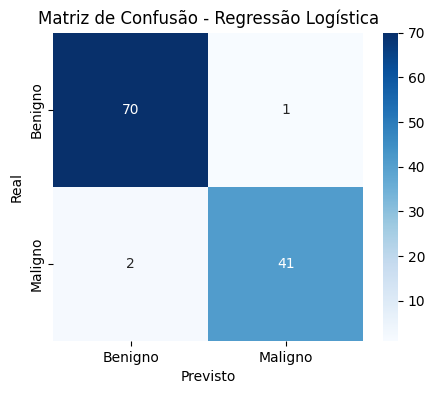

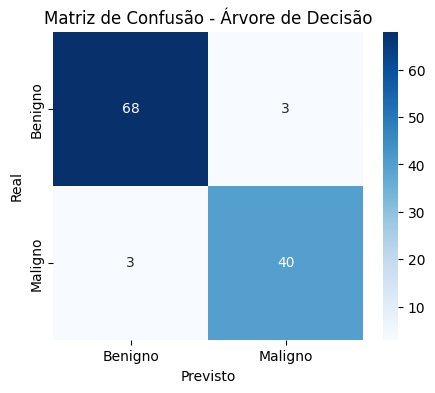

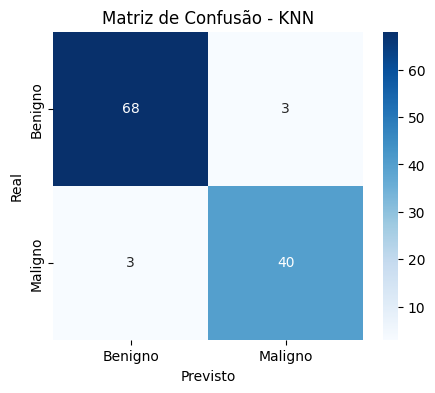

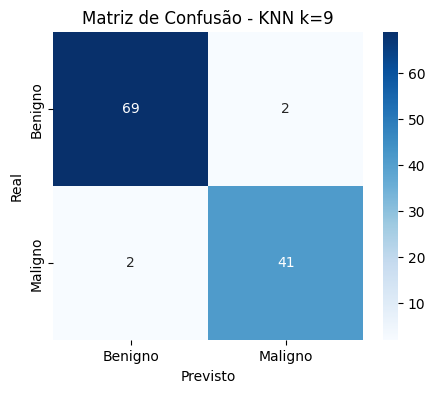

In [3]:
# Importa bibliotecas de visualização e a função para matriz de confusão
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Percorre novamente os modelos para visualizar onde cada um acerta e erra
for nome, modelo in modelos.items():
    # Treina o modelo com os dados padronizados
    modelo.fit(X_train_scaled, y_train)
    y_pred = modelo.predict(X_test_scaled)

    # Gera a matriz de confusão comparando valores reais e previstos
    cm = confusion_matrix(y_test, y_pred)

    # Cria o gráfico de calor para facilitar a interpretação visual
    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=['Benigno', 'Maligno'],
        yticklabels=['Benigno', 'Maligno']
    )

    # Adiciona título e rótulos para deixar o gráfico mais claro
    plt.title(f'Matriz de Confusão - {nome}')
    plt.xlabel('Previsto')
    plt.ylabel('Real')
    plt.show()

### Análise

| Modelo              | TN | FP | FN | TP | Interpretação                                            |
| ------------------- | -: | -: | -: | -: | -------------------------------------------------------- |
| Regressão Logística | 70 |  1 |  2 | 41 | Melhor equilíbrio inicial, com apenas 2 falsos negativos |
| Árvore de Decisão   | 68 |  3 |  3 | 40 | Errou mais casos malignos                 |
| KNN                 | 68 |  3 |  3 | 40 | Errou mais casos malignos                                 |
| KNN k=9             | 69 |  2 |  2 | 41 | Melhorou em relação ao KNN k=5 (próximo ao Regressão Logística)                           |

A matriz de confusão foi utilizada para avaliar os tipos de acertos e erros dos modelos.

No contexto deste projeto, a classe 0 representa tumores benignos e a classe 1 representa tumores malignos. Assim, o erro mais crítico é o falso negativo, quando um tumor maligno é classificado como benigno.

Entre os modelos avaliados, a Regressão Logística apresentou o melhor equilíbrio inicial, com 70 verdadeiros negativos, 41 verdadeiros positivos, 1 falso positivo e 2 falsos negativos.







### Validação cruzada K-Fold

In [4]:
# Importa as ferramentas necessárias para validação cruzada e criação de pipelines
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Define uma validação cruzada estratificada para manter a proporção das classes em cada dobra
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Monta pipelines para evitar vazamento de dados durante a validação cruzada
pipelines = {
    'Regressão Logística': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(max_iter=1000, random_state=42))
    ]),
    'Árvore de Decisão': Pipeline([
        ('model', DecisionTreeClassifier(max_depth=5, random_state=42))
    ]),
    'KNN': Pipeline([
        ('scaler', StandardScaler()),
        ('model', KNeighborsClassifier(n_neighbors=5))
    ])
}

# Define quais métricas serão calculadas em cada rodada da validação cruzada
scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1'
}

# Lista que irá armazenar a média das métricas por modelo
resultados_cv = []

# Executa a validação cruzada para cada pipeline e resume os resultados
for nome, pipeline in pipelines.items():
    scores = cross_validate(
        pipeline,
        X,
        y,
        cv=cv,
        scoring=scoring
    )

    resultados_cv.append({
        'Modelo': nome,
        'Acurácia Média': scores['test_accuracy'].mean(),
        'Precisão Média': scores['test_precision'].mean(),
        'Recall Médio': scores['test_recall'].mean(),
        'F1-score Médio': scores['test_f1'].mean()
    })

# Exibe os resultados médios em formato tabular
df_cv = pd.DataFrame(resultados_cv)
df_cv

,Modelo,Acurácia Média,Precisão Média,Recall Médio,F1-score Médio
0,Regressão Logística,0.973669,0.986258,0.943632,0.963341
1,Árvore de Decisão,0.927993,0.929353,0.877852,0.899202
2,KNN,0.963096,0.975524,0.924585,0.948669


### Ajuste de hiperparâmetros com GridSearchCV

GridSearchCV para Regressão Logística

In [5]:
# Define o recall como métrica prioritária no ajuste, pois queremos minimizar falsos negativos
scoring = 'recall'

# Importa a ferramenta de busca em grade para testar várias combinações de hiperparâmetros
from sklearn.model_selection import GridSearchCV

# Monta o pipeline da regressão logística com padronização antes do modelo
pipeline_logistica = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=5000, random_state=42))
])

# Define os hiperparâmetros que serão testados para a regressão logística
param_grid_logistica = {
    'model__C': [0.01, 0.1, 1, 10, 100],
    'model__solver': ['liblinear', 'lbfgs']
}

# Executa a busca pelos melhores parâmetros usando validação cruzada
grid_logistica = GridSearchCV(
    pipeline_logistica,
    param_grid_logistica,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

# Treina todas as combinações possíveis e seleciona a melhor
grid_logistica.fit(X_train, y_train)

# Mostra quais parâmetros produziram o melhor recall médio
print('Melhores parâmetros:', grid_logistica.best_params_)
print('Melhor recall médio:', grid_logistica.best_score_)

Melhores parâmetros: {'model__C': 10, 'model__solver': 'liblinear'}
Melhor recall médio: 0.9584670231729057


Avaliação no teste:

              precision    recall  f1-score   support

           0       0.99      0.97      0.98        71
           1       0.95      0.98      0.97        43

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



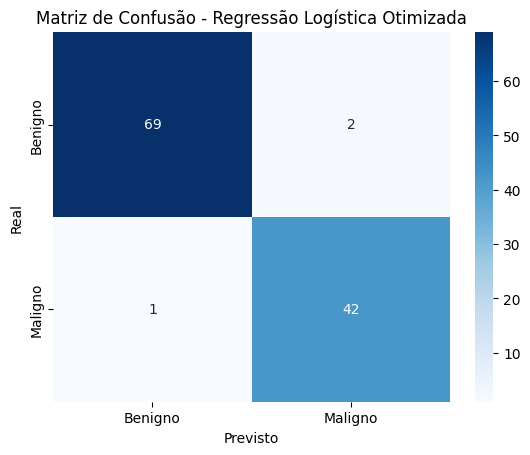

In [6]:
# Recupera o melhor modelo encontrado no GridSearchCV
melhor_logistica = grid_logistica.best_estimator_

# Gera previsões no conjunto de teste para avaliar o desempenho fora do treino
y_pred_grid_logistica = melhor_logistica.predict(X_test)

# Exibe métricas detalhadas de classificação por classe
print(classification_report(y_test, y_pred_grid_logistica))

# Calcula a matriz de confusão da melhor regressão logística
cm = confusion_matrix(y_test, y_pred_grid_logistica)

# Plota a matriz para visualizar acertos, falsos positivos e falsos negativos
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Benigno', 'Maligno'],
    yticklabels=['Benigno', 'Maligno']
)

# Adiciona título e rótulos ao gráfico
plt.title('Matriz de Confusão - Regressão Logística Otimizada')
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.show()

### Análise

Após a otimização com GridSearchCV (Melhores parâmetros: {'model__C': 10, 'model__solver': 'liblinear'}), a Regressão Logística apresentou melhora na identificação da classe maligna, reduzindo os falsos negativos para apenas 1 caso. Esse resultado é relevante no contexto médico, pois reduz o risco de deixar de identificar um tumor maligno.


GridSearchCV para KNN

In [7]:
# Monta o pipeline do KNN com padronização, etapa importante para modelos baseados em distância
pipeline_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('model', KNeighborsClassifier())
])

# Define a grade de hiperparâmetros a ser testada para o KNN
param_grid_knn = {
    'model__n_neighbors': [3, 5, 7, 9, 11, 13, 15],
    'model__weights': ['uniform', 'distance'],
    'model__metric': ['euclidean', 'manhattan']
}

# Procura a melhor combinação com foco em recall
grid_knn = GridSearchCV(
    pipeline_knn,
    param_grid_knn,
    cv=cv,
    scoring='recall',
    n_jobs=-1
)

# Treina o grid search e identifica o melhor conjunto de hiperparâmetros
grid_knn.fit(X_train, y_train)

# Exibe os melhores parâmetros encontrados e o melhor recall médio
print('Melhores parâmetros:', grid_knn.best_params_)
print('Melhor recall médio:', grid_knn.best_score_)

Melhores parâmetros: {'model__metric': 'manhattan', 'model__n_neighbors': 3, 'model__weights': 'uniform'}
Melhor recall médio: 0.9292335115864526


Avaliação:

In [8]:
# Recupera o melhor pipeline encontrado para o KNN
melhor_knn = grid_knn.best_estimator_

# Faz previsões no conjunto de teste
y_pred_grid_knn = melhor_knn.predict(X_test)

# Exibe o relatório completo com precisão, recall e F1-score
print(classification_report(y_test, y_pred_grid_knn))

              precision    recall  f1-score   support

           0       0.97      0.97      0.97        71
           1       0.95      0.95      0.95        43

    accuracy                           0.96       114
   macro avg       0.96      0.96      0.96       114
weighted avg       0.96      0.96      0.96       114



### Análise

Considerando que o erro mais grave seria um falso negativo (FN) "Tumor maligno considerado como benigno" podendo ter risco de morte, atraso. Vamos fazer o recall da classe maligna. Análisamos quantos malignos conseguimos identificar.

** Analisando a tabela temos:
- Recall (maligno) = 0.95 --> Temos yuma taxa de 95% dos malignos identificados.
Em numeros reais, de 43 casos, 41 correto.

Com isto entendemos que o modelo de forma nenhuma substitui uma análise médica.


### GridSearchCV para Árvore de Decisão

In [9]:
# Cria o pipeline da árvore de decisão
pipeline_tree = Pipeline([
    ('model', DecisionTreeClassifier(random_state=42))
])

# Define a grade de hiperparâmetros que será testada
param_grid_tree = {
    'model__max_depth': [2, 3, 4, 5, 6, 8, 10, None],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4],
    'model__criterion': ['gini', 'entropy']
}

# Executa o GridSearchCV para encontrar a melhor configuração da árvore
grid_tree = GridSearchCV(
    pipeline_tree,
    param_grid_tree,
    cv=cv,
    scoring='recall',
    n_jobs=-1
)

# Ajusta o modelo em todas as combinações da grade
grid_tree.fit(X_train, y_train)

# Mostra a melhor configuração encontrada e o recall médio correspondente
print('Melhores parâmetros:', grid_tree.best_params_)
print('Melhor recall médio:', grid_tree.best_score_)

Melhores parâmetros: {'model__criterion': 'entropy', 'model__max_depth': 2, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2}
Melhor recall médio: 0.9470588235294117


### Comparar modelos otimizados

In [10]:
# Agrupa os melhores modelos encontrados em cada estratégia de otimização
modelos_otimizados = {
    'Regressão Logística Otimizada': grid_logistica.best_estimator_,
    'KNN Otimizado': grid_knn.best_estimator_,
    'Árvore Otimizada': grid_tree.best_estimator_
}

# Lista que receberá as métricas dos modelos otimizados
resultados_otimizados = []

# Avalia cada melhor modelo no conjunto de teste
for nome, modelo in modelos_otimizados.items():
    y_pred = modelo.predict(X_test)

    resultados_otimizados.append({
        'Modelo': nome,
        'Acurácia': accuracy_score(y_test, y_pred),
        'Precisão Classe 1': precision_score(y_test, y_pred, pos_label=1),
        'Recall Classe 1': recall_score(y_test, y_pred, pos_label=1),
        'F1-score Classe 1': f1_score(y_test, y_pred, pos_label=1)
    })

# Organiza os resultados em tabela para comparação final
df_resultados_otimizados = pd.DataFrame(resultados_otimizados)
df_resultados_otimizados

,Modelo,Acurácia,Precisão Classe 1,Recall Classe 1,F1-score Classe 1
0,Regressão Logística Otimizada,0.973684,0.954545,0.976744,0.965517
1,KNN Otimizado,0.964912,0.953488,0.953488,0.953488
2,Árvore Otimizada,0.912281,0.836735,0.953488,0.891304


### Interpretabilidade do modelo

- Regressão Logística (melhor modelo)

| Modelo                 | Recall     |
| ---------------------- | ---------- |
| Regressão Logística | **0.9767** |
| KNN                    | 0.9535     |
| Árvore                 | 0.9535     |


maior recall → detecta mais câncer
melhor acurácia
melhor equilíbrio geral

- KNN
Recall bom, próximo a Regressão Logística

- Arvore de Decisão
Pior precisão, acurácia e F1

Opção 1: coeficientes da Regressão Logística

In [11]:
# Acessa apenas o estimador final dentro do pipeline otimizado de regressão logística
melhor_modelo_logistico = grid_logistica.best_estimator_.named_steps['model']

# Cria uma tabela ligando cada variável ao seu coeficiente no modelo
coeficientes = pd.DataFrame({
    'Variável': X.columns,
    'Coeficiente': melhor_modelo_logistico.coef_[0]
})

# Calcula o valor absoluto para medir a intensidade do impacto de cada variável
coeficientes['Impacto Absoluto'] = coeficientes['Coeficiente'].abs()

# Ordena da variável mais influente para a menos influente
coeficientes = coeficientes.sort_values(
    by='Impacto Absoluto',
    ascending=False
)

# Exibe as 10 variáveis com maior impacto na decisão do modelo
coeficientes.head(10)

,Variável,Coeficiente,Impacto Absoluto
10,raio_erro_padrao,3.476705,3.476705
7,pontos_concavos_media,3.282150,3.282150
5,compactacao_media,-2.690291,2.690291
28,simetria_pior,2.596807,2.596807
26,concavidade_pior,2.547744,2.547744
21,textura_pior,2.491912,2.491912
13,area_erro_padrao,2.316666,2.316666
23,area_pior,1.946042,1.946042
20,raio_pior,1.814519,1.814519
16,concavidade_erro_padrao,-1.693637,1.693637


Na Regressão Logística, os coeficientes indicam quais variáveis mais influenciam a classificação. Coeficientes positivos aumentam a chance de classificação como maligno, enquanto coeficientes negativos reduzem essa chance. A análise dos maiores valores absolutos permite identificar as variáveis mais relevantes para o modelo.

In [12]:
# Extrai o modelo de árvore de decisão de dentro do pipeline otimizado
melhor_arvore = grid_tree.best_estimator_.named_steps['model']

# Cria uma tabela com a importância atribuída a cada variável pela árvore
importancias = pd.DataFrame({
    'Variável': X.columns,
    'Importância': melhor_arvore.feature_importances_
})

# Ordena da variável mais importante para a menos importante
importancias = importancias.sort_values(
    by='Importância',
    ascending=False
)

# Mostra as 10 variáveis mais relevantes segundo a árvore
importancias.head(10)

,Variável,Importância
7,pontos_concavos_media,0.761452
22,perimetro_pior,0.136251
20,raio_pior,0.102297
3,area_media,0.000000
2,perimetro_media,0.000000
0,raio_media,0.000000
5,compactacao_media,0.000000
6,concavidade_media,0.000000
8,simetria_media,0.000000
9,dimensao_fractal_media,0.000000


Gráfico:

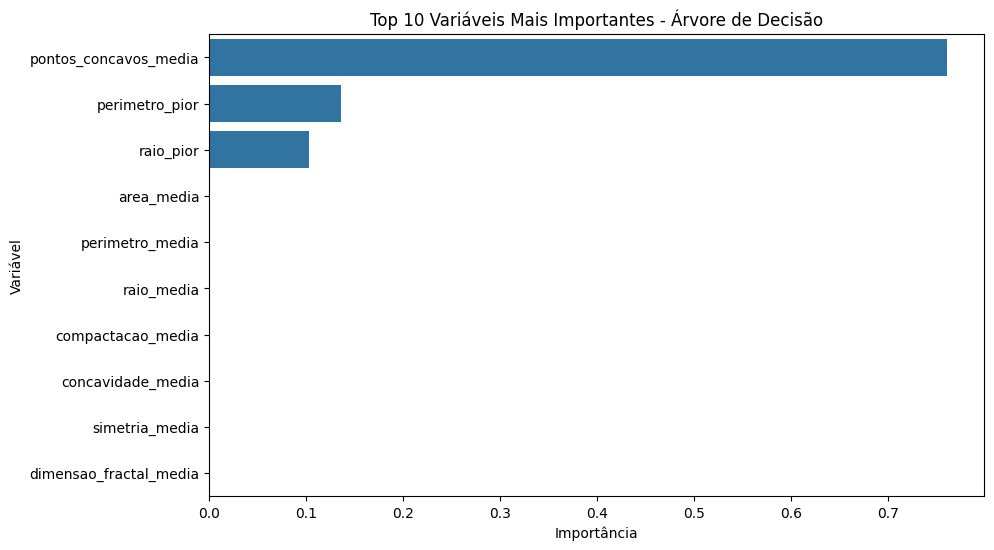

In [13]:
# Seleciona apenas as 10 variáveis mais importantes para facilitar a visualização
top_importancias = importancias.head(10)

# Cria um gráfico de barras horizontal com as importâncias da árvore
plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_importancias,
    x='Importância',
    y='Variável'
)

# Configura título e rótulos do gráfico
plt.title('Top 10 Variáveis Mais Importantes - Árvore de Decisão')
plt.xlabel('Importância')
plt.ylabel('Variável')
plt.show()

### SHapley Additive exPlanations

Por que o modelo disse que esse tumor é maligno?”

Exemplo: 

- +0.30 → raio alto
- +0.25 → área grande
- +0.20 → concavidade alta
- -0.05 → textura baixa

Soma de 0.80 (exemplo, não é probabilidade real, tem outros fatores considerado no modelo), neste caso 0.80 consideramos Maligno.

O tumor tem:
- raio maior
- área maior
- alta concavidade
- muitos pontos côncavos


### Comparação do Recall com Classe Maligna

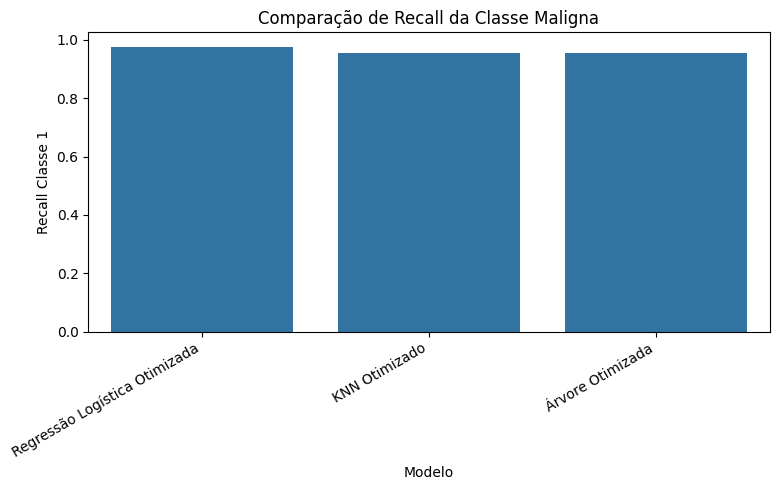

In [14]:
# Importa Path para criar pastas de saída de forma portátil
from pathlib import Path

# Garante que as pastas para figuras e tabelas existam
Path('../reports/figures').mkdir(parents=True, exist_ok=True)
Path('../reports/tables').mkdir(parents=True, exist_ok=True)

# Salva as tabelas de resultados em CSV para uso posterior no relatório
df_resultados.to_csv('../reports/tables/comparacao_modelos_base.csv', index=False)
df_cv.to_csv('../reports/tables/validacao_cruzada.csv', index=False)
df_resultados_otimizados.to_csv('../reports/tables/comparacao_modelos_otimizados.csv', index=False)

# Cria um gráfico comparando o recall da classe maligna entre os modelos otimizados
plt.figure(figsize=(8, 5))
sns.barplot(
    data=df_resultados_otimizados,
    x='Modelo',
    y='Recall Classe 1'
)

# Ajusta apresentação do gráfico para salvar uma figura legível
plt.title('Comparação de Recall da Classe Maligna')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()

# Salva a imagem na pasta de figuras e exibe o resultado na tela
plt.savefig('../reports/figures/comparacao_recall_classe_maligna.png', dpi=300)
plt.show()

Foram avaliados três modelos de classificação: Regressão Logística, Árvore de Decisão e KNN. A Regressão Logística apresentou o melhor desempenho inicial, com acurácia de 0,9737 e recall de 0,95 para a classe maligna. A Árvore de Decisão e o KNN apresentaram desempenho semelhante, ambos com acurácia de 0,9474 e recall de 0,93 para a classe maligna.

No contexto médico, a métrica mais relevante é o recall da classe positiva, pois ela mede a capacidade do modelo de identificar corretamente os casos malignos. Um falso negativo, ou seja, classificar um tumor maligno como benigno, pode causar atraso no diagnóstico e comprometer o tratamento do paciente. Por isso, mesmo que a acurácia seja importante, a escolha do modelo deve priorizar o recall da classe maligna.

A matriz de confusão reforça essa análise, pois permite observar diretamente quantos casos malignos foram classificados incorretamente como benignos. Modelos com menor número de falsos negativos são mais adequados para aplicações de apoio ao diagnóstico.

### Analise final

Entendo que o melhor modelo foi a regressão linear, sem seguida do KNN considerando 9 vizinho.

Entendo também que considerando ser um caso médido, é melhor ter um falso positivo (para maligno), do que um falso negativo, ou seja é melhor dizer "maligno" e depois descobrir que é benigno.

Desta forma entendi que deve fazer o recall da classe 1, para conseguir encontrar o maximo de casos malignos.

Com isso decidi alterar o nível de decisão "thershold", melhorando a probabilidade de maligno.

In [16]:
from sklearn.metrics import classification_report, confusion_matrix, recall_score, precision_score, f1_score, accuracy_score
import pandas as pd

# Treinar o modelo
modelo = LogisticRegression(max_iter=1000, random_state=42)
modelo.fit(X_train_scaled, y_train)

# Obter probabilidades da classe 1, ou seja, maligno
y_proba = modelo.predict_proba(X_test_scaled)[:, 1]

# Testar diferentes thresholds
thresholds = [0.50, 0.45, 0.40, 0.35, 0.30, 0.25]

resultados_threshold = []

for threshold in thresholds:
    y_pred_threshold = (y_proba >= threshold).astype(int)

    cm = confusion_matrix(y_test, y_pred_threshold)

    tn, fp, fn, tp = cm.ravel()

    resultados_threshold.append({
        'Threshold': threshold,
        'Acurácia': accuracy_score(y_test, y_pred_threshold),
        'Precisão Classe 1': precision_score(y_test, y_pred_threshold, pos_label=1),
        'Recall Classe 1': recall_score(y_test, y_pred_threshold, pos_label=1),
        'F1-score Classe 1': f1_score(y_test, y_pred_threshold, pos_label=1),
        'TN': tn,
        'FP': fp,
        'FN': fn,
        'TP': tp
    })

df_threshold = pd.DataFrame(resultados_threshold)
df_threshold

,Threshold,Acurácia,Precisão Classe 1,Recall Classe 1,F1-score Classe 1,TN,FP,FN,TP
0,0.50,0.973684,0.976190,0.953488,0.964706,70,1,2,41
1,0.45,0.982456,0.976744,0.976744,0.976744,70,1,1,42
2,0.40,0.982456,0.976744,0.976744,0.976744,70,1,1,42
3,0.35,0.973684,0.954545,0.976744,0.965517,69,2,1,42
4,0.30,0.956140,0.913043,0.976744,0.943820,67,4,1,42
5,0.25,0.956140,0.913043,0.976744,0.943820,67,4,1,42


### Principal Conclusão

O melhor ponto para a tabela deve ser o 0.45, pois a partir deste valor não obtivemos melhora na identificação dos malignos. Desta forma entendo também que o unico caso não identificado baseado no 0.45 pode ser considerado uma exceção.

### Threshold 0.50
- Acertou 70 benignos.
- Errou 1 benigno como maligno.
- Deixou passar 2 malignos como benignos.
- Acertou 41 malignos.

### Threshold 0.45
- Acertou 70 benignos.
- Errou 1 benigno como maligno.
- Deixou passar apenas 1 maligno como benigno.
- Acertou 42 malignos.